In [1]:
import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')
print(df)

if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:

    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")
# Extract gene and score
result = df[['gene_symbol', score_col]]

# Sort by score in descending order
result = result.sort_values(by=score_col, ascending=False)

# Display the result
print(result)

# Save to a CSV file
result.to_csv('mdd_genes_with_scores.csv', index=False)

import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Filter for genes with score >= 0.65
high_score_genes = df[df[score_col] >= 0.70].copy()

# Extract gene and score
filtered_result = high_score_genes[['gene_symbol', score_col]]

# Sort by score in descending order
filtered_result = filtered_result.sort_values(by=score_col, ascending=False)

# Display the result
print(f"Found {len(filtered_result)} genes with score >= 0.70")
#print((filtered_result))

pd.set_option('display.max_rows', None)

# Print only the desired columns
print(filtered_result)
# Save to a CSV file
#filtered_result.to_csv('mdd_genes_high_score.csv', index=False)

# Optional: Add a label column
filtered_result['MDD_Label'] = 'High_Confidence_MDD_Gene'

# Save the labeled version
#result.to_csv('mdd_genes_high_score_labeled.csv', index=False)

           ei  numCTs                                       pathway_name  \
0    0.903846       2                                Signal Transduction   
1    0.830645      68  Signal Transduction,Disease,Immune System,Meta...   
2    0.871642      64  Signal Transduction,Disease,Gene expression (T...   
3    0.855556       6                                    Neuronal System   
4    0.764151      44                                      Immune System   
..        ...     ...                                                ...   
224  1.000000       0                                                NaN   
225  1.000000       0                                                NaN   
226  1.000000       0                              Developmental Biology   
227  1.000000       0          Developmental Biology,Signal Transduction   
228  1.000000       0  Metabolism of proteins,Cellular responses to s...   

    gene_symbol  numVariantsAssociatedToGene              gp_class_names  \
0         H

COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES

1. BASIC STATISTICS
----------------------------------------
Total number of genes: 229
Average score: 0.624
Median score: 0.600
Score standard deviation: 0.119
Minimum score: 0.500
Maximum score: 0.950

2. SCORE DISTRIBUTION BY QUANTILES
----------------------------------------
25th percentile: 0.500
50th percentile: 0.600
75th percentile: 0.700
90th percentile: 0.800
95th percentile: 0.850

3. GENE COUNT BY SCORE THRESHOLDS
----------------------------------------
Genes with score ≥ 0.3: 229 (100.0%)
Genes with score ≥ 0.5: 229 (100.0%)
Genes with score ≥ 0.7: 62 (27.1%)
Genes with score ≥ 0.8: 33 (14.4%)
Genes with score ≥ 0.9: 6 (2.6%)

4. TOP 10 HIGHEST SCORING GENES
----------------------------------------
HTR1A: 0.950
IL6: 0.950
BDNF: 0.950
SLC6A4: 0.950
CRP: 0.950
GRM5: 0.900
CRH: 0.850
CYP2C19: 0.850
CYP2D6: 0.850
NR3C1: 0.850

5. GENERATING VISUALIZATIONS
----------------------------------------
Visualizations saved as 'mdd_genes

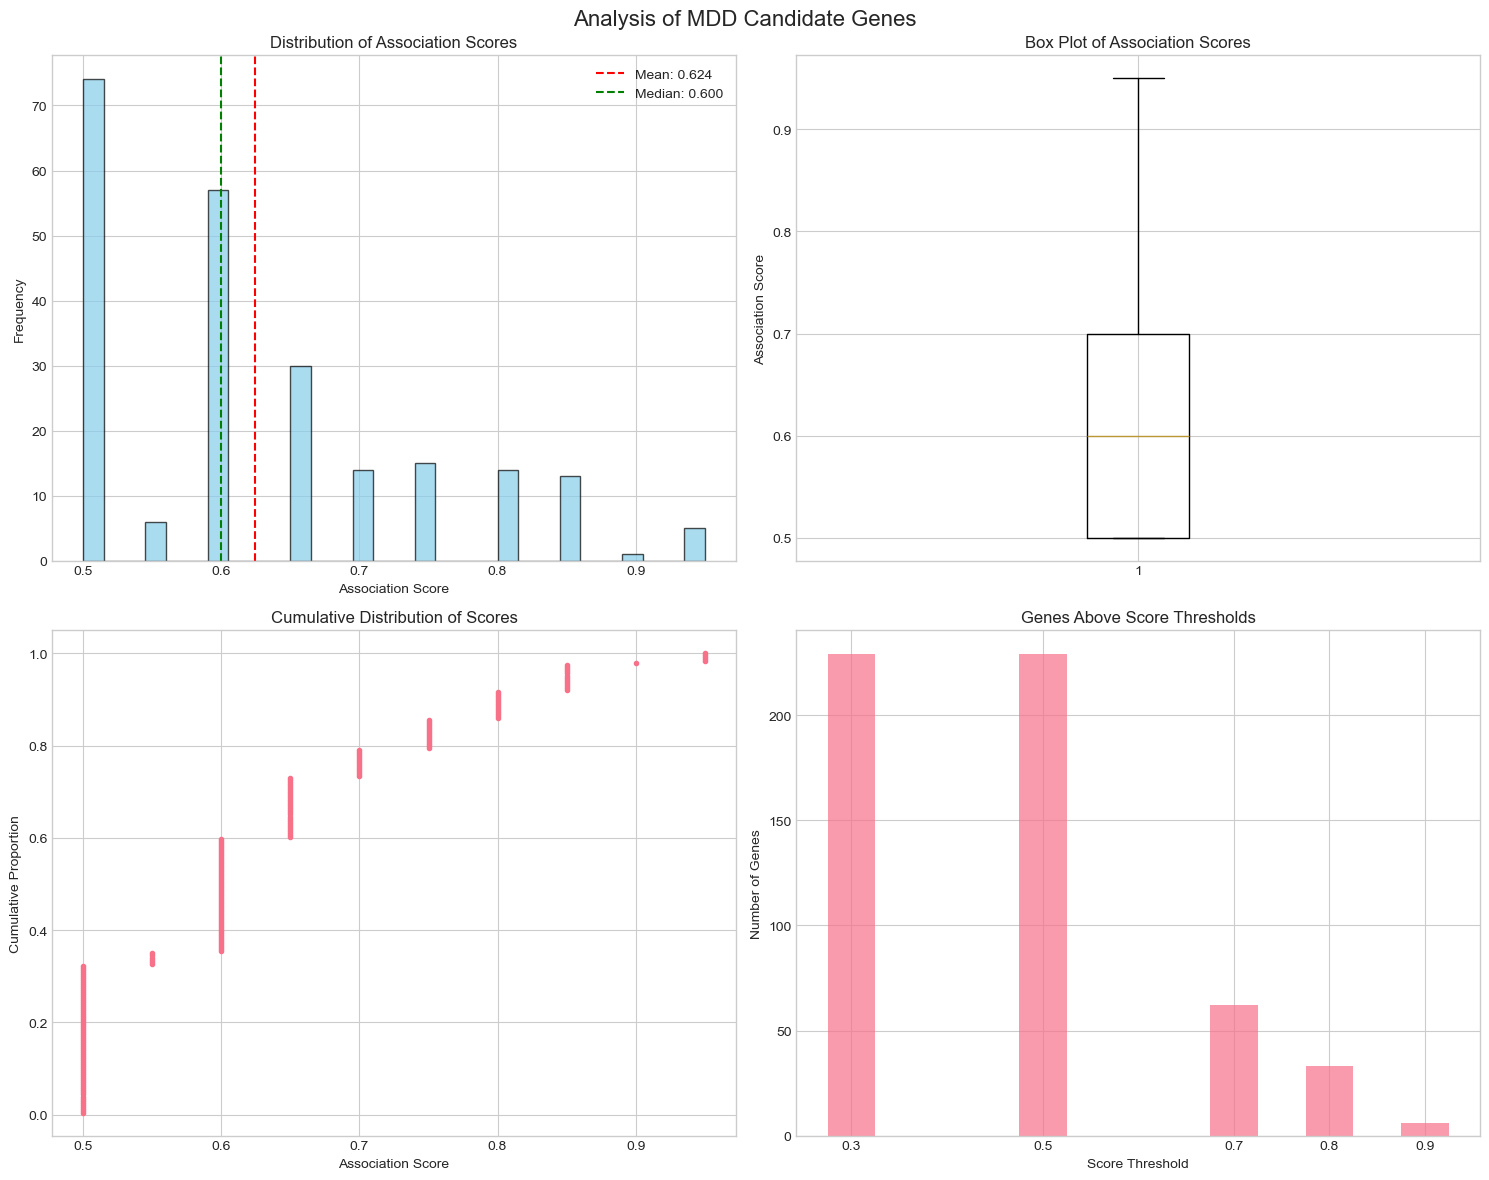

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def analyze_mdd_genes(df, score_column='score'):
    """
    Perform comprehensive analysis on MDD candidate genes
    
    Parameters:
    df (DataFrame): DataFrame containing MDD genes and their scores
    score_column (str): Name of the column containing association scores
    """
    
    print("=" * 60)
    print("COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES")
    print("=" * 60)
    
    # 1. Basic statistics
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    print(f"Total number of genes: {len(df)}")
    print(f"Average score: {df[score_column].mean():.3f}")
    print(f"Median score: {df[score_column].median():.3f}")
    print(f"Score standard deviation: {df[score_column].std():.3f}")
    print(f"Minimum score: {df[score_column].min():.3f}")
    print(f"Maximum score: {df[score_column].max():.3f}")
    
    # 2. Score distribution by quantiles
    print("\n2. SCORE DISTRIBUTION BY QUANTILES")
    print("-" * 40)
    quantiles = df[score_column].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
    for q, value in quantiles.items():
        print(f"{int(q*100)}th percentile: {value:.3f}")
    
    # 3. Count genes by score thresholds
    print("\n3. GENE COUNT BY SCORE THRESHOLDS")
    print("-" * 40)
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    for threshold in thresholds:
        count = len(df[df[score_column] >= threshold])
        print(f"Genes with score ≥ {threshold}: {count} ({count/len(df)*100:.1f}%)")
    
    # 4. Top 10 highest scoring genes
    print("\n4. TOP 10 HIGHEST SCORING GENES")
    print("-" * 40)
    top_genes = df.nlargest(10, score_column)[['gene_symbol', score_column]]
    for _, row in top_genes.iterrows():
        print(f"{row['gene_symbol']}: {row[score_column]:.3f}")
    
    # 5. Visualizations
    print("\n5. GENERATING VISUALIZATIONS")
    print("-" * 40)
    
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of MDD Candidate Genes', fontsize=16)
    
    # Distribution of scores
    axes[0, 0].hist(df[score_column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df[score_column].mean(), color='red', linestyle='--', label=f'Mean: {df[score_column].mean():.3f}')
    axes[0, 0].axvline(df[score_column].median(), color='green', linestyle='--', label=f'Median: {df[score_column].median():.3f}')
    axes[0, 0].set_xlabel('Association Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Association Scores')
    axes[0, 0].legend()
    
    # Box plot of scores
    axes[0, 1].boxplot(df[score_column])
    axes[0, 1].set_ylabel('Association Score')
    axes[0, 1].set_title('Box Plot of Association Scores')
    
    # Cumulative distribution
    sorted_scores = np.sort(df[score_column])
    cum_dist = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
    axes[1, 0].plot(sorted_scores, cum_dist, marker='.', linestyle='none')
    axes[1, 0].set_xlabel('Association Score')
    axes[1, 0].set_ylabel('Cumulative Proportion')
    axes[1, 0].set_title('Cumulative Distribution of Scores')
    axes[1, 0].grid(True)
    
    # Score thresholds
    threshold_counts = [len(df[df[score_column] >= t]) for t in thresholds]
    axes[1, 1].bar(thresholds, threshold_counts, width=0.05, alpha=0.7)
    axes[1, 1].set_xlabel('Score Threshold')
    axes[1, 1].set_ylabel('Number of Genes')
    axes[1, 1].set_title('Genes Above Score Thresholds')
    axes[1, 1].set_xticks(thresholds)
    
    plt.tight_layout()
    plt.savefig('mdd_genes_analysis.png', dpi=300, bbox_inches='tight')
    print("Visualizations saved as 'mdd_genes_analysis.png'")
    
    # 6. Additional analyses if other columns are available
    if 'Gene Type' in df.columns:
        print("\n6. GENE TYPE DISTRIBUTION")
        print("-" * 40)
        gene_type_counts = df['Gene Type'].value_counts()
        print("Top gene types:")
        for gene_type, count in gene_type_counts.head(10).items():
            print(f"  {gene_type}: {count} genes")
            
        # Plot gene type distribution
        plt.figure(figsize=(10, 6))
        gene_type_counts.head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top 10 Gene Types in MDD Candidates')
        plt.xlabel('Gene Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('mdd_gene_types.png', dpi=300, bbox_inches='tight')
        print("Gene type distribution saved as 'mdd_gene_types.png'")
    
    if 'Pathways' in df.columns:
        print("\n7. PATHWAY ANALYSIS")
        print("-" * 40)
        # Extract and count pathways
        all_pathways = []
        for pathways in df['Pathways'].dropna():
            # Assuming pathways are separated by semicolons
            pathway_list = [p.strip() for p in pathways.split(';')]
            all_pathways.extend(pathway_list)
        
        pathway_counts = pd.Series(all_pathways).value_counts()
        print("Top pathways associated with MDD genes:")
        for pathway, count in pathway_counts.head(10).items():
            print(f"  {pathway}: {count} genes")
    
    # 8. Save detailed analysis results
    analysis_results = {
        'total_genes': len(df),
        'mean_score': df[score_column].mean(),
        'median_score': df[score_column].median(),
        'std_score': df[score_column].std(),
        'min_score': df[score_column].min(),
        'max_score': df[score_column].max(),
        'quantiles': quantiles.to_dict(),
        'threshold_counts': {f"geq_{t}": len(df[df[score_column] >= t]) for t in thresholds},
        'top_genes': top_genes.to_dict('records')
    }
    
    # Convert to DataFrame and save
    analysis_df = pd.DataFrame.from_dict(analysis_results, orient='index')
    analysis_df.to_csv('mdd_genes_analysis_summary.csv', header=['Value'])
    print("\nAnalysis summary saved as 'mdd_genes_analysis_summary.csv'")
    
    return analysis_results

# Load your data
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Run the analysis
analysis_results = analyze_mdd_genes(df, score_col)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

In [4]:
import pandas as pd

pd.reset_option('display.max_rows')

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_97.tsv" 
brain_only_df = pd.read_csv(file_path, sep='\t')


brain_only_df = brain_only_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain:")
print(brain_only_df)

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_restrictedbrain.tsv" 
brain_restricted_df = pd.read_csv(file_path, sep='\t')


brain_restricted_df = brain_restricted_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain and in less than 1/3 of other tissues:")
print(brain_restricted_df)


# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_all_tissues.tsv" 
all_tissues_df = pd.read_csv(file_path, sep='\t')


all_tissues_df = all_tissues_df[['Gene']]


# Display the result
print("The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):")
print(all_tissues_df)



print('List of common genes between all MDD genes and the genes only existing in brain are:')
common_df = result[result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes only existing in brain are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in less than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes existing brain and less than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))

print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in more than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes in more than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))



#concat MDD genes with Brain genes
import pandas as pd

print("Node set 1 contains the restricted genes (Genes in brain and less than 1/3 of all tissues + Genes only in brain:)")
node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        result['gene_symbol'], 
        brain_restricted_df['Gene']
    ], ignore_index=True)
})

node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        node_set1['Genes'], 
        brain_only_df['Gene']
    ], ignore_index=True)
})
print(node_set1)


print("----------------------")
print("\n")

print("Node set 2 contains the all brain genes (And all other tissues))")
node_set2 = pd.DataFrame({
    'Genes': pd.concat([
        all_tissues_df['Gene'], 
        node_set1['Genes']
    ], ignore_index=True)
})
print(node_set2)

print("----------------------")
print("\n")

print("Here the node set is assigned to the nodes in our network: ")
all_nodes = node_set1

print(all_nodes)



import requests

# Gene list
gene_list = all_nodes['Genes'].dropna().unique().tolist()
print(f"Number of input genes: {len(gene_list)}")

# STRING API settings
STRING_API_URL = "https://string-db.org/api/tsv-no-header/network"
payload = {
    "identifiers": "\n".join(gene_list),  # newline-separated
    "species": 9606,
    "required_score": 400
}

# Use POST to avoid URL length limit
response = requests.post(STRING_API_URL, data=payload)

if response.ok:
    interactions = []
    for line in response.text.strip().split("\n"):
        cols = line.split("\t")
        try:
            gene_a = cols[2]  # preferredName_A
            gene_b = cols[3]  # preferredName_B
            
            score = float(cols[5])  # combined_score
            interactions.append((gene_a, gene_b, score))
           # print(interactions)
        except (IndexError, ValueError):
            continue
    print(f"Number of interactions found: {len(interactions)}")
else:
    print("Error:", response.status_code, response.text)

for i in range(0,10):
    print(interactions[i])


import networkx as nx

G = nx.Graph()

# Add nodes
G.add_nodes_from(gene_list)

# Add edges with STRING score as weight
for gene_a, gene_b, score in interactions:
    G.add_edge(gene_a, gene_b, weight=score)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")



The genes that only exist in human's brain:
              Gene
0             AMBN
1             AMZ1
2         ANKRD34C
3          ANKRD63
4   ARMCX5-GPRASP2
..             ...
92        TMEM132D
93           TRPC5
94            UCMA
95            VAX1
96            WNT1

[97 rows x 1 columns]
The genes that only exist in human's brain and in less than 1/3 of other tissues:
         Gene
0       A2ML1
1      ABCC12
2       ABCG4
3     ABHD12B
4        ACAN
...       ...
1359   ZNF732
1360  ZNF804A
1361   ZNF831
1362   ZNF843
1363      ZP2

[1364 rows x 1 columns]
The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):
        Gene
0     A4GALT
1      AADAT
2       AARD
3       AASS
4       AATK
...      ...
4966  ZSWIM4
4967  ZSWIM5
4968  ZSWIM9
4969   ZWINT
4970    ZXDA

[4971 rows x 1 columns]
List of common genes between all MDD genes and the genes only existing in brain are:
    gene_symbol  score
93         DRD3    0.6
111       HTR3B    0.6
118  

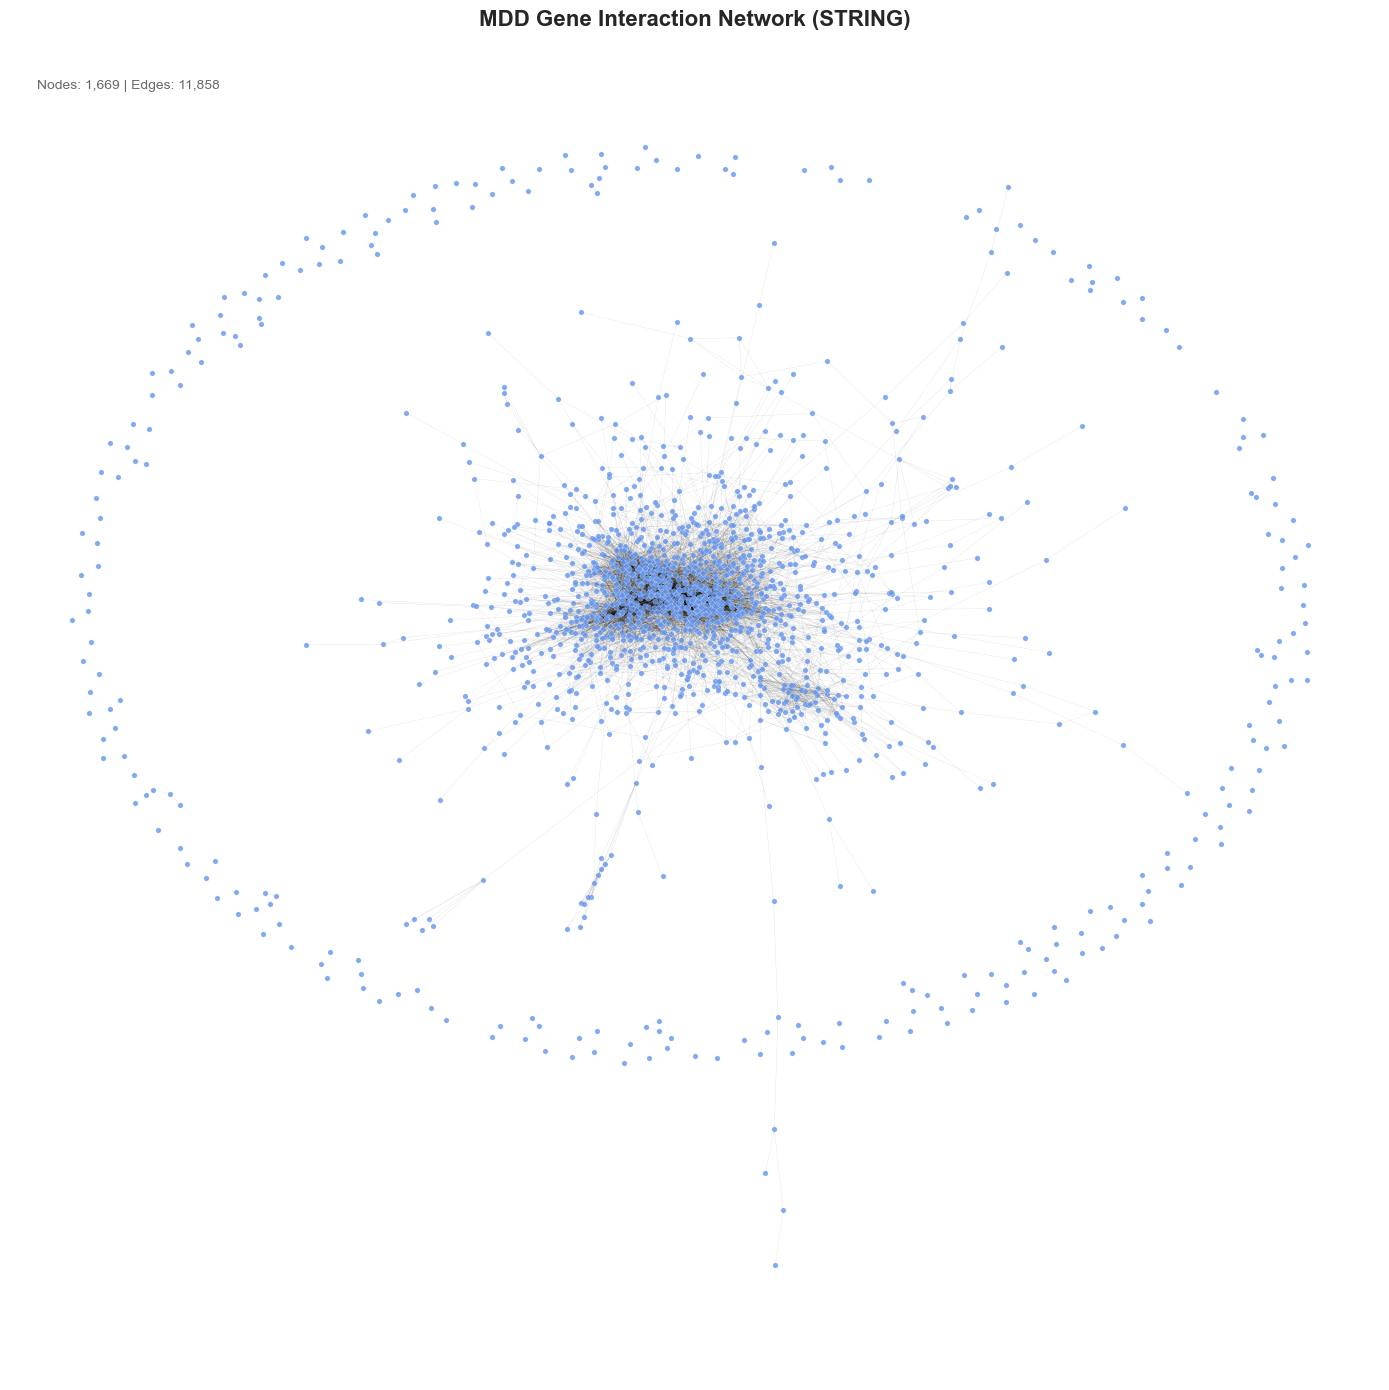

In [6]:
#Another graph!
import matplotlib.pyplot as plt
import networkx as nx

# Set style for cleaner look
plt.style.use("seaborn-v0_8-white")

# Create the layout (spring layout can be slow, so this uses fewer iterations)
pos = nx.spring_layout(G, k=0.08, iterations=50, seed=42)

# Initialize figure
plt.figure(figsize=(14, 14))
plt.title("MDD Gene Interaction Network (STRING)", fontsize=16, fontweight='bold', pad=20)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=15,
    node_color="cornflowerblue",
    alpha=0.8,
    linewidths=0.2,
    edgecolors="white"
)

# Draw edges (thin and transparent for clarity)
nx.draw_networkx_edges(
    G, pos,
    width=0.2,
    alpha=0.15,
    edge_color="black"
)

# Remove axes for a clean look
plt.axis("off")

# Add annotation for node/edge count
plt.text(0.02, 0.98,
         f"Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}",
         transform=plt.gca().transAxes,
         fontsize=10, color="dimgray", va="top")

plt.tight_layout()
plt.show()


Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
Scoring table built: 934 nodes (positives=60)

NEGATIVE SELECTION (30 samples; criteria identical, seed varies)
- Non-positives count: 874
- Bottom quantile q=0.5: cutoff=0.284260
- Exclude dist <= 2: ON
- Eligible negatives: 215
- Selected negatives per sample: 60 (target=60)
- Positives in graph: 60
- Negative sampling seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
  sample 00 seed=42: size=60 | outside_eligible=0 | overlap_positives=0
  sample 01 seed=43: size=60 | outside_eligible=0 | overlap_positives=0
  sample 02 seed=44: size=60 | outside_eligible=0 | overlap_positives=0
  sample 03 seed=45: size=60 | outside_eligible=0 | overlap_positives=0
  sample 04 seed=46: size

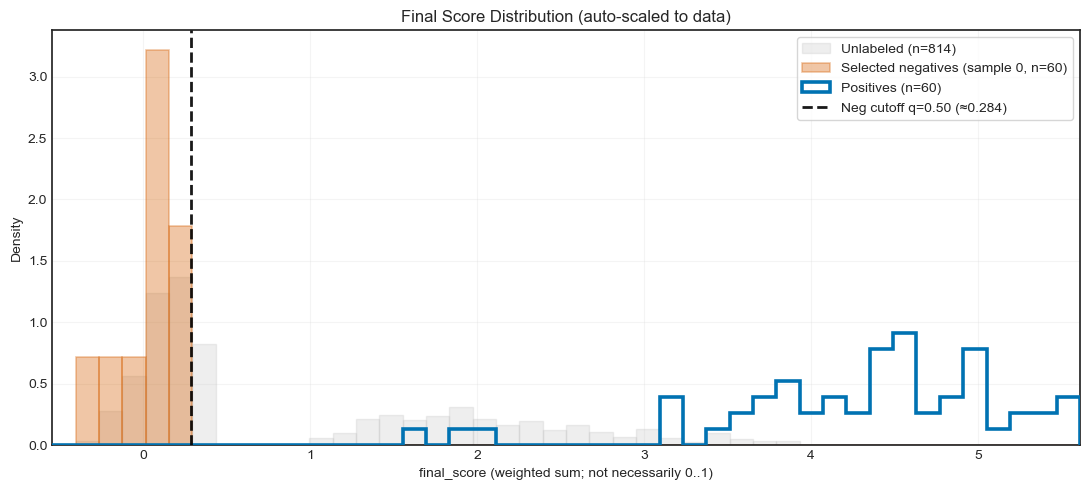

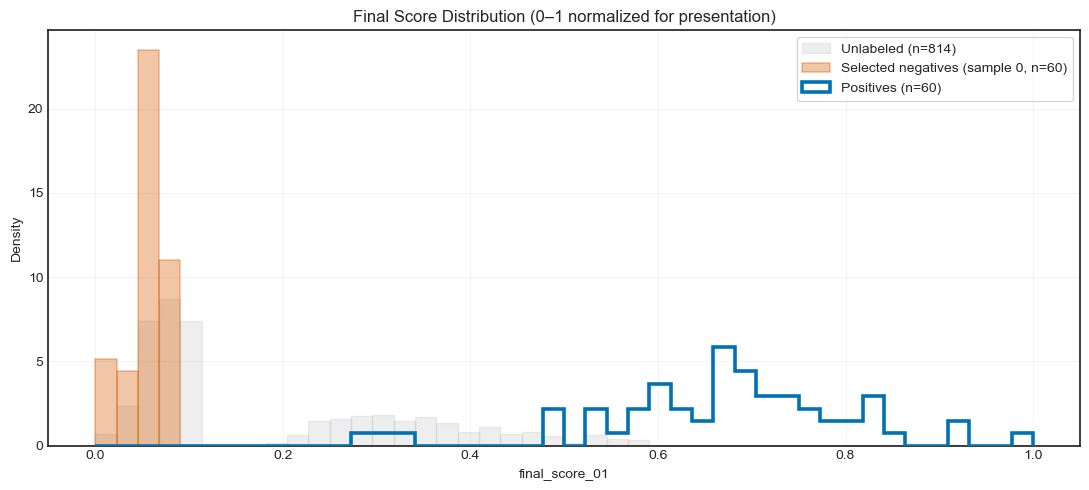

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_96766/403279947.py:356: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


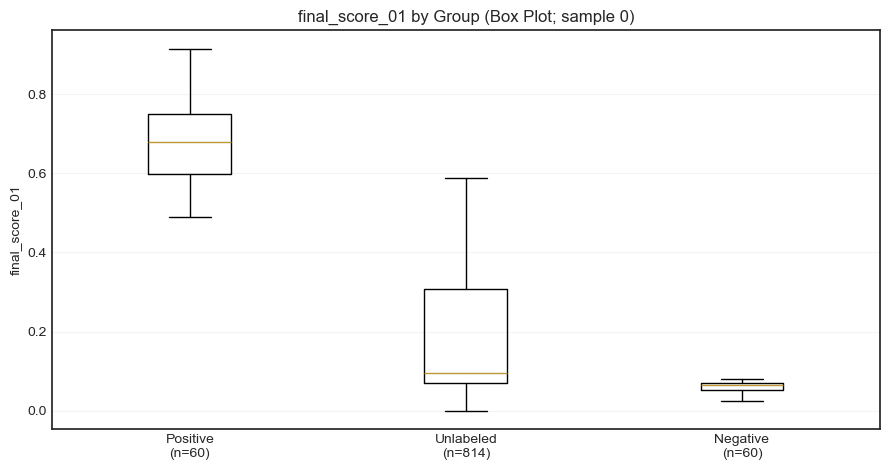


Saved:
- candidate_genes.csv (top 20 non-positive by final_score)
- refined_negative_genes_30samples_thr0.6_q0.5_excl2_k60.csv
- refined_negative_genes_SAMPLE0_thr0.6_q0.5_excl2.csv
- scored_all_nodes.csv (all nodes with features + scores + groups)


In [25]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import random
from collections import deque

# =======================================================
# FULL PIPELINE: Heuristic Scoring + Negative Selection (30 samples)
#
# IMPORTANT:
# - negatives are sampled ONLY from non-positives
# - eligible pool = bottom NEG_Q of non-positive final_score
# - optionally exclude nodes within <= EXCLUDE_DIST hops of positives
#
# CHANGES IN THIS VERSION:
# 1) keep only the part of the graph connected to at least one positive gene
# 2) generate 30 negative samples
# 3) match negatives to number of positives in the filtered graph
# 4) sort eligible genes before sampling for stable reproducibility
# =======================================================

# -----------------------------
# Config
# -----------------------------
EDGE_THRESHOLD = 0.6

NEG_Q = 0.50
EXCLUDE_DIST = 2

N_NEG_SAMPLES = 30
BASE_SEED = 42

WEIGHTS = {
    "ppr": 3.0,
    "pos_w_ratio": 2.0,
    "pos_w_sum": 1.5,
    "pos_w_max": 1.0,
    "prox": 1.5,
    "hub_penalty": -1.0
}
PROX_ALPHA = 0.7

# -----------------------------
# Helpers
# -----------------------------
def multi_source_bfs_distances(G, sources):
    dist = {n: np.inf for n in G.nodes()}
    q = deque()
    for s in sources:
        if s in G:
            dist[s] = 0
            q.append(s)
    while q:
        u = q.popleft()
        for v in G.neighbors(u):
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def summarize_scores(name, arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        print(f"{name:10s}: n=0")
        return
    q01, q25, q50, q75, q99 = np.quantile(arr, [0.01, 0.25, 0.50, 0.75, 0.99])
    print(
        f"{name:10s}: n={arr.size:<6d} min={arr.min(): .6f}  p01={q01: .6f}  "
        f"p25={q25: .6f}  med={q50: .6f}  p75={q75: .6f}  p99={q99: .6f}  max={arr.max(): .6f}"
    )

def auto_bins(all_scores, n_bins=45):
    lo, hi = np.quantile(all_scores, [0.01, 0.99])
    if lo == hi:
        lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
    pad = 0.05 * (hi - lo + 1e-9)
    x_min, x_max = lo - pad, hi + pad
    bins = np.linspace(x_min, x_max, n_bins)
    return bins, x_min, x_max

# =======================================================
# 1) Build Weighted Network
# =======================================================
high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

G = nx.Graph()
for a, b, w in high_conf_interactions:
    G.add_edge(str(a), str(b), weight=float(w))

print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# =======================================================
# 2) Label Positive Genes
# =======================================================
positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
nx.set_node_attributes(G, {n: (1 if n in positive_genes else 0) for n in G.nodes()}, "positive")

pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in graph before component filtering: {len(pos_in_graph)}")

# =======================================================
# 3) Keep only nodes connected to at least one positive
# =======================================================
positive_nodes_set = set(pos_in_graph)

reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_nodes_set:
        reachable_from_positive.update(comp)

removed_nodes = set(G.nodes()) - reachable_from_positive
n_removed = len(removed_nodes)

# Remove genes from components with no positive connection
G = G.subgraph(reachable_from_positive).copy()

print(f"Removed {n_removed} genes from components with no positive connection")
print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Recompute positives in filtered graph
pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in filtered graph: {len(pos_in_graph)}")

# =======================================================
# 4) Precompute Global Signals
# =======================================================
dist_to_pos = multi_source_bfs_distances(G, pos_in_graph) if len(pos_in_graph) > 0 else {n: np.inf for n in G.nodes()}

if len(pos_in_graph) > 0:
    personalization = {n: (1.0 if n in pos_in_graph else 0.0) for n in G.nodes()}
    ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="weight")
else:
    ppr = {n: 0.0 for n in G.nodes()}

deg = dict(G.degree())

# =======================================================
# 5) Feature Table for ALL nodes
# =======================================================
rows = []
eps = 1e-9

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    pos_neighbors = [n for n in neighbors if G.nodes[n].get("positive", 0) == 1]

    pos_edges = [G[node][p]["weight"] for p in pos_neighbors]
    pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
    pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
    pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
    pos_neighbor_count = len(pos_neighbors)

    total_w = float(np.sum([G[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
    pos_w_ratio = pos_w_sum / (total_w + eps)

    d = dist_to_pos.get(node, np.inf)
    prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    hub_penalty = float(np.log1p(deg.get(node, 0)))

    rows.append({
        "gene": node,
        "is_positive": int(G.nodes[node].get("positive", 0) == 1),
        "pos_neighbor_count": pos_neighbor_count,
        "pos_w_sum": pos_w_sum,
        "pos_w_max": pos_w_max,
        "pos_w_mean": pos_w_mean,
        "pos_w_ratio": pos_w_ratio,
        "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
        "prox": prox,
        "ppr": float(ppr.get(node, 0.0)),
        "hub_penalty": hub_penalty
    })

scored = pd.DataFrame(rows)
print(f"Scoring table built: {len(scored)} nodes (positives={int(scored['is_positive'].sum())})")

# =======================================================
# 6) Normalize features + Composite Final Score
# =======================================================
score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

if np.isinf(scored["distance_to_positive"]).any():
    reachable = scored.loc[~np.isinf(scored["distance_to_positive"]), "distance_to_positive"]
    worst = float(reachable.max()) + 1 if len(reachable) else 1.0
    scored["distance_to_positive"] = scored["distance_to_positive"].replace(np.inf, worst)

scaler = MinMaxScaler()
scored[score_features] = scaler.fit_transform(scored[score_features])

scored["final_score"] = 0.0
for f, w in WEIGHTS.items():
    scored["final_score"] += scored[f] * float(w)

scored["final_score_01"] = MinMaxScaler().fit_transform(scored[["final_score"]])

scored["group"] = "unlabeled"
scored.loc[scored["is_positive"] == 1, "group"] = "positive"

# =======================================================
# 7) Choose Negatives (ONLY from non-positives) - 30 samples
# =======================================================
nonpos = scored[scored["is_positive"] == 0].copy()

cutoff = nonpos["final_score"].quantile(NEG_Q)
eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
    eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

# Sort for stable reproducibility
eligible_genes = sorted(eligible["gene"].astype(str).tolist())

# Match negatives to number of positives in filtered graph
k_target = len(pos_in_graph)
k = min(k_target, len(eligible_genes))

negative_gene_sets = []
negative_gene_sets_by_seed = {}

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    rng = random.Random(seed_i)
    neg_i = rng.sample(eligible_genes, k=k) if k > 0 else []
    negative_gene_sets.append(neg_i)
    negative_gene_sets_by_seed[seed_i] = neg_i

negatives = negative_gene_sets[0]
negative_genes = negatives

scored.loc[scored["gene"].isin(negatives), "group"] = "negative"

print(f"\nNEGATIVE SELECTION ({N_NEG_SAMPLES} samples; criteria identical, seed varies)")
print(f"- Non-positives count: {len(nonpos)}")
print(f"- Bottom quantile q={NEG_Q}: cutoff={cutoff:.6f}")
print(f"- Exclude dist <= {EXCLUDE_DIST}: {'ON' if EXCLUDE_DIST and EXCLUDE_DIST > 0 else 'OFF'}")
print(f"- Eligible negatives: {len(eligible_genes)}")
print(f"- Selected negatives per sample: {k} (target={k_target})")
print(f"- Positives in graph: {len(pos_in_graph)}")
print(f"- Negative sampling seeds: {[BASE_SEED + i for i in range(N_NEG_SAMPLES)]}")

eligible_set = set(map(str, eligible_genes))
pos_set = set(map(str, pos_in_graph))

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    neg_set = set(map(str, negative_gene_sets[i]))
    outside = len(neg_set - eligible_set)
    overlap_pos = len(neg_set & pos_set)
    print(f"  sample {i:02d} seed={seed_i}: size={len(neg_set)} | outside_eligible={outside} | overlap_positives={overlap_pos}")

# =======================================================
# 8) Print summaries (sample 0)
# =======================================================
pos_scores = scored.loc[scored["group"] == "positive", "final_score"].values
neg_scores = scored.loc[scored["group"] == "negative", "final_score"].values
unl_scores = scored.loc[scored["group"] == "unlabeled", "final_score"].values
all_scores = scored["final_score"].values

print("\n=== SCORE RANGES (final_score) ===")
summarize_scores("ALL", all_scores)
summarize_scores("POS", pos_scores)
summarize_scores("NEG", neg_scores)
summarize_scores("UNLABELED", unl_scores)

print("\n=== CONSISTENCY CHECKS ===")
print("Any positives selected as negative? ->", bool(set(negatives) & set(pos_in_graph)))
print("Counts by group (sample 0):")
print(scored["group"].value_counts().to_string())

print("\n=== TOP 10 POSITIVES by final_score ===")
print(
    scored[scored["group"] == "positive"]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

print("\n=== TOP 10 NON-POSITIVES by final_score ===")
print(
    scored[scored["is_positive"] == 0]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

# =======================================================
# 9) Visualize (sample 0)
# =======================================================
COL_UNL = "#BDBDBD"
COL_NEG = "#D55E00"
COL_POS = "#0072B2"
COL_CUT = "#000000"

bins, x_min, x_max = auto_bins(all_scores, n_bins=45)

plt.figure(figsize=(11, 5))
plt.hist(unl_scores, bins=bins, density=True, alpha=0.25,
         color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(neg_scores, bins=bins, density=True, alpha=0.35,
         color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(pos_scores, bins=bins, density=True, histtype="step",
         linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.axvline(cutoff, linestyle="--", linewidth=2, color=COL_CUT, alpha=0.9,
            label=f"Neg cutoff q={NEG_Q:.2f} (≈{cutoff:.3f})", zorder=5)

plt.xlim(x_min, x_max)
plt.title("Final Score Distribution (auto-scaled to data)")
plt.xlabel("final_score (weighted sum; not necessarily 0..1)")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

bins01 = np.linspace(0, 1, 45)
plt.figure(figsize=(11, 5))

plt.hist(scored.loc[scored["group"] == "unlabeled", "final_score_01"], bins=bins01, density=True,
         alpha=0.25, color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(scored.loc[scored["group"] == "negative", "final_score_01"], bins=bins01, density=True,
         alpha=0.35, color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(scored.loc[scored["group"] == "positive", "final_score_01"], bins=bins01, density=True,
         histtype="step", linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.title("Final Score Distribution (0–1 normalized for presentation)")
plt.xlabel("final_score_01")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
data = []
labels = []
if len(pos_scores) > 0:
    data.append(scored.loc[scored["group"] == "positive", "final_score_01"].values)
    labels.append(f"Positive\n(n={len(pos_scores)})")
if len(unl_scores) > 0:
    data.append(scored.loc[scored["group"] == "unlabeled", "final_score_01"].values)
    labels.append(f"Unlabeled\n(n={len(unl_scores)})")
if len(neg_scores) > 0:
    data.append(scored.loc[scored["group"] == "negative", "final_score_01"].values)
    labels.append(f"Negative\n(n={len(neg_scores)})")

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("final_score_01 by Group (Box Plot; sample 0)")
plt.ylabel("final_score_01")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# =======================================================
# 10) Save Results
# =======================================================
top_candidates = scored[scored["is_positive"] == 0].sort_values("final_score", ascending=False).head(20)
top_candidates.to_csv("candidate_genes.csv", index=False)

neg_long = []
for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    for g in negative_gene_sets[i]:
        neg_long.append({"sample_id": i, "seed": seed_i, "gene": g})

pd.DataFrame(neg_long).to_csv(
    f"refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv",
    index=False
)

pd.DataFrame({"gene": negatives}).to_csv(
    f"refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv",
    index=False
)

scored.to_csv("scored_all_nodes.csv", index=False)

print("\nSaved:")
print("- candidate_genes.csv (top 20 non-positive by final_score)")
print(f"- refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv")
print(f"- refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv")
print("- scored_all_nodes.csv (all nodes with features + scores + groups)")

negative_genes = negatives

=== TRAINING GAT ACROSS NEGATIVE SAMPLES (masked node classification; threshold tuned on VAL) ===
Graph nodes: 934 | directed edges: 8300
Feature dim: 20 | scored_merge=True | device=cpu
[RUN 00] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=28.1087 val_auc=0.000 val_f1~0.000
    epoch=025 loss=13.0281 val_auc=0.000 val_f1~0.095
RUN 00 | best_epoch=1 | VAL AUC 0.000 AP 0.331 | TEST AUC 0.000 AP 0.327 | t*=0.01 | TEST P 0.000 R 0.000 F1 0.000 | pred_pos=4/24 | pos_w=1.00
[RUN 01] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=7.0904 val_auc=0.910 val_f1~0.952
    epoch=025 loss=2.9907 val_auc=0.860 val_f1~0.667
    epoch=050 loss=0.4315 val_auc=0.970 val_f1~0.947
RUN 01 | best_epoch=38 | VAL AUC 1.000 AP 1.000 | TEST AUC 0.972 AP 0.979 | t*=0.01 | TEST P 1.000 R 0.917 F1 0.957 | pred_pos=11/24 | pos_w=1.00
[RUN 02] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=10.3334 val_auc=0.880 val_f1~0.741
    epoch=025 loss=2.4163 val_auc=0.200 val_f1~0.

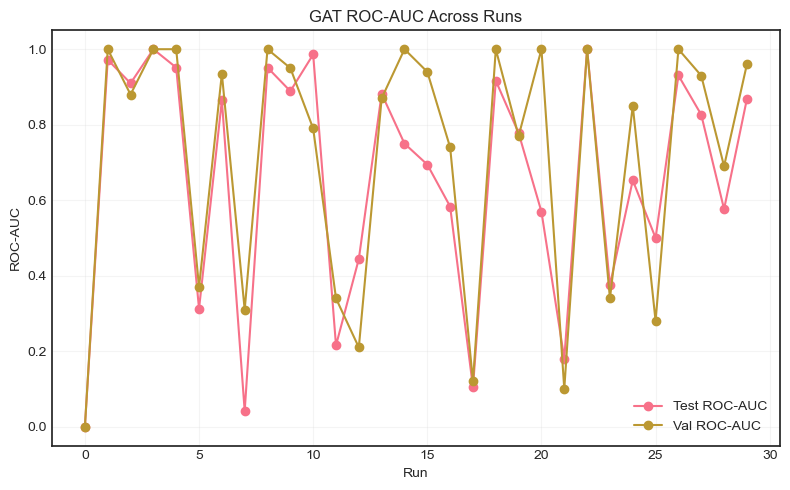

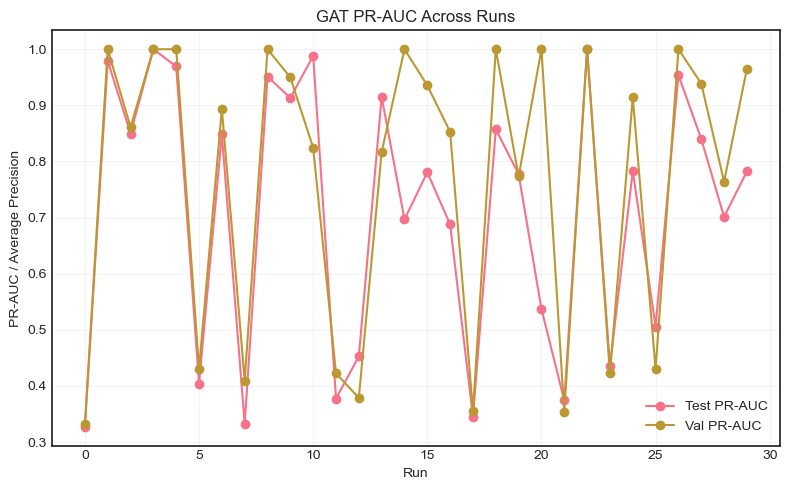

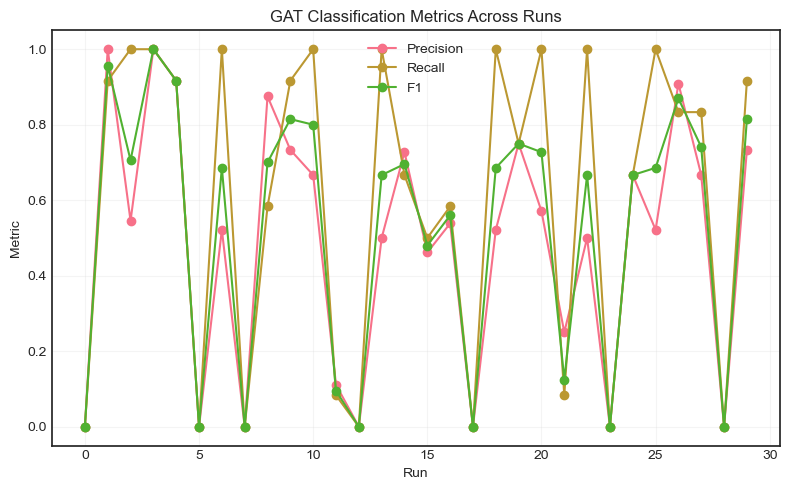

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_96766/1467914489.py:608: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=["Test AUC", "Test AP", "Precision", "Recall", "F1"], showfliers=True)


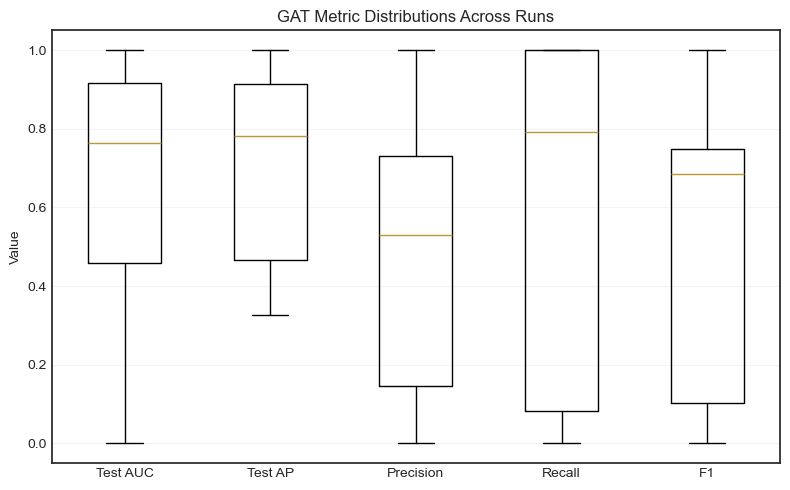


Saved: gat_neg_sampling_30runs_results_val_tuned_threshold.csv

Stored GAT models for ranking: 30

Ready for next cell:
- results_df, summary_df
- gat_models_per_run (per-run trained GAT + threshold + feature_cols)


In [27]:
# ============================================================
# SELF-CONTAINED GAT (multi-run, masked node classification, reproducible)
# - Rebuilds scored_lookup if missing (from 'scored' DataFrame)
# - Tunes threshold on VAL (max F1)
# - Reports ROC-AUC + PR-AUC (AP) for VAL and TEST
# - Stores gat_models_per_run for averaged ranking later
# - Updated for 30 negative sets
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support
)

print("=== TRAINING GAT ACROSS NEGATIVE SAMPLES (masked node classification; threshold tuned on VAL) ===")

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

FORCE_CPU = True
if FORCE_CPU:
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

# -----------------------------
# Preconditions
# -----------------------------
if "G" not in globals():
    raise RuntimeError("G not found. Build the graph first.")
if "negative_gene_sets" not in globals():
    raise RuntimeError("negative_gene_sets not found. Run your negative sampling cell first.")
if "positive_genes" not in globals():
    raise RuntimeError("positive_genes not found.")

if "scored_lookup" not in globals():
    if "scored" not in globals():
        raise RuntimeError("Neither scored_lookup nor scored found. Run your scoring/negative-sampling cell first.")
    SCORED_COLS = [
        "gene",
        "ppr",
        "pos_w_ratio",
        "pos_w_sum",
        "pos_w_max",
        "pos_neighbor_count",
        "distance_to_positive",
        "prox",
        "hub_penalty",
        "final_score",
        "final_score_01",
    ]
    available_scored_cols = [c for c in SCORED_COLS if c in scored.columns]
    scored_lookup = (
        scored[available_scored_cols]
        .copy()
        .assign(gene=lambda d: d["gene"].astype(str))
        .drop_duplicates(subset=["gene"])
        .set_index("gene")
    )
    print(f"Rebuilt scored_lookup from scored (cols={len(available_scored_cols)})")

# -----------------------------
# Config
# -----------------------------
EXPECTED_RUNS = 30

SPLIT_SEED = 42
N_EPOCHS = 200
PATIENCE = 30
LR = 0.005
WEIGHT_DECAY = 5e-4

# Safer GAT defaults for this small-label setting
HIDDEN = 16
DROPOUT = 0.3
ATTN_DROPOUT = 0.3
HEADS = 2

SCORED_MERGE = True

n_runs = len(negative_gene_sets)
if n_runs != EXPECTED_RUNS:
    print(f"Warning: expected {EXPECTED_RUNS} negative sets, but found {n_runs}. Running with {n_runs} sets.")

# -----------------------------
# Precompute structural features
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)

def extract_structural_features(graph, gene):
    gene = str(gene)
    if gene not in graph:
        return None
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    return {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
        "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
        "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
        "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }

# -----------------------------
# Global node indexing
# -----------------------------
nodes = [str(n) for n in G.nodes()]
node_to_idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

# -----------------------------
# edge_index (undirected -> doubled)
# -----------------------------
edges = []
for u, v in G.edges():
    u = str(u)
    v = str(v)
    if u in node_to_idx and v in node_to_idx:
        ui = node_to_idx[u]
        vi = node_to_idx[v]
        edges.append((ui, vi))
        edges.append((vi, ui))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
num_edges_dir = edge_index.size(1)

# -----------------------------
# Build all-node feature matrix X once
# -----------------------------
def build_all_node_features(graph):
    rows = []
    for g in nodes:
        r = extract_structural_features(graph, g)
        if r is None:
            r = {"gene": g}
        if SCORED_MERGE and (g in scored_lookup.index):
            s = scored_lookup.loc[g].to_dict()
            s.pop("gene", None)
            r.update(s)
        r["gene"] = g
        rows.append(r)

    df = pd.DataFrame(rows).fillna(0)
    df = df.replace([np.inf, -np.inf], 0)

    genes = df["gene"].astype(str).values
    X_df = df.drop(columns=["gene"]).copy()

    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce").fillna(0.0)

    return genes, X_df

all_genes, X_df = build_all_node_features(G)
feature_cols = list(X_df.columns)
X = torch.tensor(X_df.values, dtype=torch.float32)

print(f"Graph nodes: {N} | directed edges: {num_edges_dir}")
print(f"Feature dim: {X.shape[1]} | scored_merge={SCORED_MERGE} | device={DEVICE}")

# -----------------------------
# GAT layer
# -----------------------------
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=2, dropout=0.3, attn_dropout=0.3, concat=True):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.attn_dropout = attn_dropout

        self.W = nn.Linear(in_dim, out_dim * heads, bias=False)
        self.a_src = nn.Parameter(torch.empty(size=(heads, out_dim)))
        self.a_dst = nn.Parameter(torch.empty(size=(heads, out_dim)))
        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_uniform_(self.a_src, gain=1.414)
        nn.init.xavier_uniform_(self.a_dst, gain=1.414)

        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, X, edge_index, num_nodes):
        src, dst = edge_index[0], edge_index[1]

        X = F.dropout(X, p=self.dropout, training=self.training)
        H = self.W(X)
        H = H.view(num_nodes, self.heads, self.out_dim)

        H_src = H[src]
        H_dst = H[dst]

        e = (H_src * self.a_src).sum(dim=-1) + (H_dst * self.a_dst).sum(dim=-1)
        e = self.leaky_relu(e)

        if hasattr(torch.Tensor, "index_reduce_"):
            e_max = torch.full((num_nodes, self.heads), -1e9, device=X.device, dtype=X.dtype)
            e_max.index_reduce_(0, dst, e, reduce="amax")
        else:
            e_max = torch.full((num_nodes, self.heads), -1e9, device=X.device, dtype=X.dtype)
            order = torch.argsort(dst)
            dst_s = dst[order]
            e_s = e[order]
            start = 0
            while start < dst_s.numel():
                end = start
                d0 = int(dst_s[start].item())
                while end < dst_s.numel() and int(dst_s[end].item()) == d0:
                    end += 1
                e_max[d0] = torch.max(e_max[d0], e_s[start:end].max(dim=0).values)
                start = end

        e_stable = e - e_max[dst]
        attn = torch.exp(e_stable)

        denom = torch.zeros((num_nodes, self.heads), device=X.device, dtype=X.dtype)
        denom.index_add_(0, dst, attn)
        alpha = attn / (denom[dst] + 1e-12)
        alpha = F.dropout(alpha, p=self.attn_dropout, training=self.training)

        out = torch.zeros((num_nodes, self.heads, self.out_dim), device=X.device, dtype=X.dtype)
        out.index_add_(0, dst, alpha.unsqueeze(-1) * H_src)

        if self.concat:
            out = out.reshape(num_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=1)
        return out

class GAT(nn.Module):
    def __init__(self, in_dim, hid_dim, heads=2, dropout=0.3, attn_dropout=0.3):
        super().__init__()
        self.gat1 = GATLayer(in_dim, hid_dim, heads=heads, dropout=dropout, attn_dropout=attn_dropout, concat=True)
        self.gat2 = GATLayer(hid_dim * heads, 1, heads=1, dropout=dropout, attn_dropout=attn_dropout, concat=False)
        self.dropout = dropout

    def forward(self, X, edge_index, num_nodes):
        h = self.gat1(X, edge_index, num_nodes)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.gat2(h, edge_index, num_nodes).squeeze(-1)
        return out

# -----------------------------
# Metrics helpers
# -----------------------------
def sigmoid_np(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))

def make_masks(labeled_idx, y_labeled, split_seed=42, val_frac=0.2, test_frac=0.2):
    rng = np.random.RandomState(split_seed)
    labeled_idx = np.asarray(labeled_idx)
    y_labeled = np.asarray(y_labeled).astype(int)

    pos = labeled_idx[y_labeled == 1]
    neg = labeled_idx[y_labeled == 0]
    rng.shuffle(pos)
    rng.shuffle(neg)

    def split_class(arr):
        n = len(arr)
        n_test = int(np.round(test_frac * n))
        n_val = int(np.round(val_frac * (n - n_test)))
        test = arr[:n_test]
        val = arr[n_test:n_test+n_val]
        train = arr[n_test+n_val:]
        return train, val, test

    pos_tr, pos_va, pos_te = split_class(pos)
    neg_tr, neg_va, neg_te = split_class(neg)

    train_idx = np.concatenate([pos_tr, neg_tr])
    val_idx   = np.concatenate([pos_va, neg_va])
    test_idx  = np.concatenate([pos_te, neg_te])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)

    train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
    val_mask[torch.tensor(val_idx, dtype=torch.long)] = True
    test_mask[torch.tensor(test_idx, dtype=torch.long)] = True

    return train_mask, val_mask, test_mask

def best_threshold_by_f1(logits, y_all, mask_bool):
    mask = mask_bool.detach().cpu().numpy().astype(bool)
    y = y_all.detach().cpu().numpy()[mask].astype(int)
    l = logits.detach().cpu().numpy()[mask]
    p = sigmoid_np(l)

    thresholds = np.linspace(0.01, 0.99, 99)
    best = {"t": 0.5, "p": 0.0, "r": 0.0, "f1": -1.0}
    for t in thresholds:
        yhat = (p >= t).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
        f1 = float(f1)
        if f1 > best["f1"]:
            best = {"t": float(t), "p": float(prec), "r": float(rec), "f1": f1}
    return best

def eval_on_mask(logits, y_all, mask_bool, threshold):
    mask = mask_bool.detach().cpu().numpy().astype(bool)
    y = y_all.detach().cpu().numpy()[mask].astype(int)
    l = logits.detach().cpu().numpy()[mask]
    prob = sigmoid_np(l)
    yhat = (prob >= threshold).astype(int)

    auc = safe_auc(y, prob)
    ap  = safe_ap(y, prob)

    prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
    return {
        "auc": auc,
        "ap": ap,
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "n": int(mask.sum()),
        "pos": int((y == 1).sum()),
        "neg": int((y == 0).sum()),
        "pred_pos": int((yhat == 1).sum())
    }

# -----------------------------
# Build labels for each run
# -----------------------------
def build_labels_for_run(pos_genes, neg_genes):
    y = torch.full((N,), -1, dtype=torch.long)
    pos_set = set(map(str, pos_genes))
    neg_set = set(map(str, neg_genes))

    labeled_idx = []
    y_labeled = []

    for g in pos_set:
        if g in node_to_idx:
            labeled_idx.append(node_to_idx[g])
            y_labeled.append(1)
            y[node_to_idx[g]] = 1
    for g in neg_set:
        if g in node_to_idx:
            labeled_idx.append(node_to_idx[g])
            y_labeled.append(0)
            y[node_to_idx[g]] = 0

    return y, np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# -----------------------------
# Training across runs
# -----------------------------
X_t = X.to(DEVICE)
edge_index_t = edge_index.to(DEVICE)

all_rows = []
gat_models_per_run = []

for run_id, neg_set in enumerate(negative_gene_sets):
    run_seed = GLOBAL_SEED + run_id
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    y_all, labeled_idx, y_labeled = build_labels_for_run(positive_genes, neg_set)
    y_all = y_all.to(DEVICE)

    train_mask, val_mask, test_mask = make_masks(
        labeled_idx=labeled_idx,
        y_labeled=y_labeled,
        split_seed=SPLIT_SEED,
        val_frac=0.2,
        test_frac=0.2
    )
    train_mask = train_mask.to(DEVICE)
    val_mask = val_mask.to(DEVICE)
    test_mask = test_mask.to(DEVICE)

    y_train_np = y_all[train_mask].detach().cpu().numpy()
    n_pos = int((y_train_np == 1).sum())
    n_neg = int((y_train_np == 0).sum())
    pos_weight = float(n_neg / max(1, n_pos))

    model = GAT(
        in_dim=X_t.shape[1],
        hid_dim=HIDDEN,
        heads=HEADS,
        dropout=DROPOUT,
        attn_dropout=ATTN_DROPOUT
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

    best_val_auc = -np.inf
    best_state = None
    best_epoch = 0
    bad = 0

    print(f"[RUN {run_id:02d}] labeled={len(labeled_idx)} (pos={int((y_labeled==1).sum())}, neg={int((y_labeled==0).sum())}) | device={DEVICE}")

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        logits = model(X_t, edge_index_t, N)
        loss = loss_fn(logits[train_mask], y_all[train_mask].float())
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(X_t, edge_index_t, N)

        y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
        val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
        val_auc = safe_auc(y_val, val_prob)

        improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
        if improved:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch == 1 or epoch % 25 == 0:
            if not np.isnan(val_auc) and len(np.unique(y_val)) == 2:
                bt_tmp = best_threshold_by_f1(logits_eval, y_all, val_mask)
                val_f1 = bt_tmp["f1"]
            else:
                val_f1 = 0.0
            print(f"    epoch={epoch:03d} loss={loss.item():.4f} val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} val_f1~{val_f1:.3f}")

        if bad >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits_final = model(X_t, edge_index_t, N)

    bt = best_threshold_by_f1(logits_final, y_all, val_mask)
    t_star = bt["t"]

    val_metrics = eval_on_mask(logits_final, y_all, val_mask, threshold=t_star)
    test_metrics = eval_on_mask(logits_final, y_all, test_mask, threshold=t_star)

    print(
        f"RUN {run_id:02d} | best_epoch={best_epoch} | "
        f"VAL AUC {val_metrics['auc']:.3f} AP {val_metrics['ap']:.3f} | "
        f"TEST AUC {test_metrics['auc']:.3f} AP {test_metrics['ap']:.3f} | "
        f"t*={t_star:.2f} | "
        f"TEST P {test_metrics['precision']:.3f} R {test_metrics['recall']:.3f} F1 {test_metrics['f1']:.3f} "
        f"| pred_pos={test_metrics['pred_pos']}/{test_metrics['n']} | pos_w={pos_weight:.2f}"
    )

    all_rows.append({
        "run": run_id,
        "model": "GAT",
        "labeled": int(len(labeled_idx)),
        "train_pos": int(n_pos),
        "train_neg": int(n_neg),
        "pos_weight": float(pos_weight),
        "best_epoch": int(best_epoch),
        "val_auc": float(val_metrics["auc"]),
        "val_ap": float(val_metrics["ap"]),
        "test_auc": float(test_metrics["auc"]),
        "test_ap": float(test_metrics["ap"]),
        "threshold": float(t_star),
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "f1": float(test_metrics["f1"]),
        "test_pred_pos": int(test_metrics["pred_pos"]),
        "test_n": int(test_metrics["n"]),
        "gat_heads": int(HEADS),
        "hidden": int(HIDDEN),
    })

    gat_models_per_run.append({
        "run_id": run_id,
        "model_name": "GAT",
        "model": model,
        "feature_cols": feature_cols,
        "node_to_idx": node_to_idx,
        "threshold": float(t_star),
        "device": str(DEVICE),
        "scored_merge": bool(SCORED_MERGE),
        "gat_heads": int(HEADS),
        "positive_genes_list": list(map(str, positive_genes)),
        "negative_genes_list": list(map(str, neg_set)),
    })

results_df = pd.DataFrame(all_rows)

print("\n=== SUMMARY (GAT across runs; threshold tuned on VAL) ===")
summary_df = results_df[["val_auc","val_ap","test_auc","test_ap","precision","recall","f1"]].agg(["mean","std"]).round(4)
print(summary_df.to_string())

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["test_auc"], marker="o", label="Test ROC-AUC")
plt.plot(results_df["run"], results_df["val_auc"], marker="o", label="Val ROC-AUC")
plt.xlabel("Run")
plt.ylabel("ROC-AUC")
plt.title("GAT ROC-AUC Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["test_ap"], marker="o", label="Test PR-AUC")
plt.plot(results_df["run"], results_df["val_ap"], marker="o", label="Val PR-AUC")
plt.xlabel("Run")
plt.ylabel("PR-AUC / Average Precision")
plt.title("GAT PR-AUC Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["precision"], marker="o", label="Precision")
plt.plot(results_df["run"], results_df["recall"], marker="o", label="Recall")
plt.plot(results_df["run"], results_df["f1"], marker="o", label="F1")
plt.xlabel("Run")
plt.ylabel("Metric")
plt.title("GAT Classification Metrics Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
box_data = [
    results_df["test_auc"].values,
    results_df["test_ap"].values,
    results_df["precision"].values,
    results_df["recall"].values,
    results_df["f1"].values,
]
plt.boxplot(box_data, labels=["Test AUC", "Test AP", "Precision", "Recall", "F1"], showfliers=True)
plt.title("GAT Metric Distributions Across Runs")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

results_df.to_csv("gat_neg_sampling_30runs_results_val_tuned_threshold.csv", index=False)
print("\nSaved: gat_neg_sampling_30runs_results_val_tuned_threshold.csv")

print(f"\nStored GAT models for ranking: {len(gat_models_per_run)}")

print("\nReady for next cell:")
print("- results_df, summary_df")
print("- gat_models_per_run (per-run trained GAT + threshold + feature_cols)")

=== AVERAGED GAT RANKING ACROSS RUNS ===
Grouping mode: UNION of negatives across 30 runs
Scoring mode: MEAN over 30 runs | model=GAT
Unlabeled genes: 659
Unique unlabeled scores: 645
Top score: 0.663650 | Unlabeled genes at top score: 1
Unlabeled rows with duplicated feature vectors (RUN 0 feature space): 2 / 659

Most frequent unlabeled score values (top 10):
model_score
0.489489    3
0.465968    2
0.453870    2
0.556977    2
0.477410    2
0.584997    2
0.538231    2
0.436744    2
0.566330    2
0.473980    2


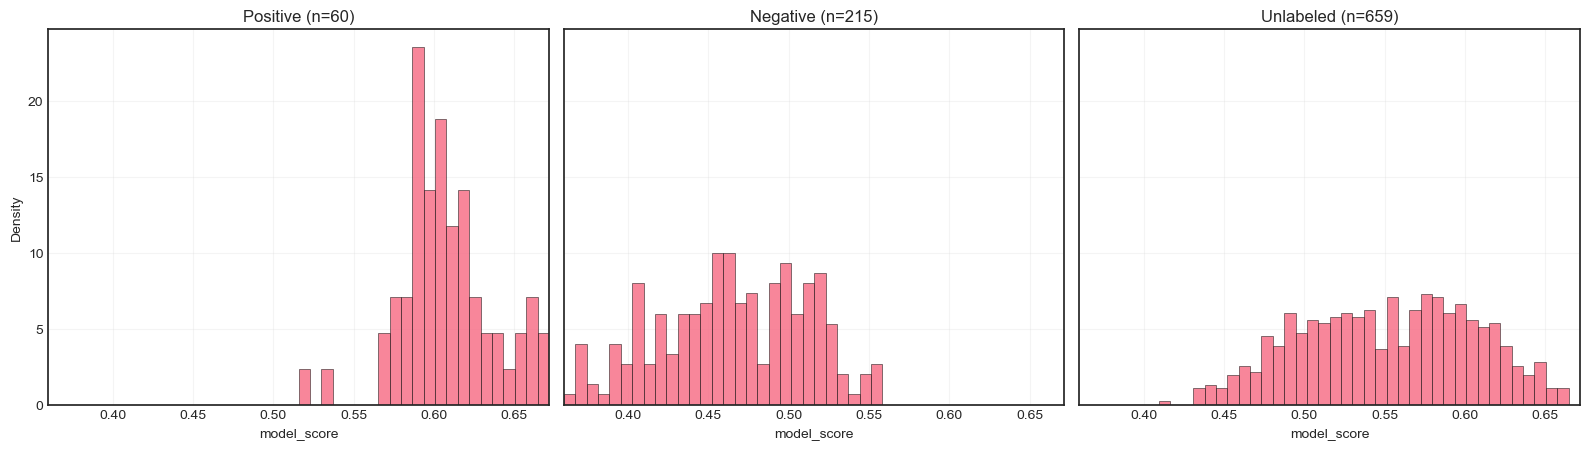


Top 40 unlabeled genes ranked by averaged GAT score:
 rank     gene  model_score  model_score_std  model_score_min  model_score_max  degree  max_neighbor_degree
    1    CCND1     0.663650         0.448843     7.545060e-15              1.0      25                 67.0
    2 SERPINE1     0.662214         0.448006     2.483766e-13              1.0      21                 67.0
    3     CHAT     0.662179         0.463095     2.651818e-17              1.0      15                 87.0
    4    HIF1A     0.662164         0.445054     1.335189e-17              1.0      31                 67.0
    5  SLC17A6     0.657607         0.447592     2.596057e-17              1.0      25                 81.0
    6  SLC32A1     0.656787         0.448010     1.984667e-16              1.0      24                 81.0
    7    NTRK3     0.654974         0.438497     7.377024e-24              1.0      10                 87.0
    8   CAMK2A     0.654813         0.461642     1.439665e-22              1.0    

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import networkx as nx

print("=== AVERAGED GAT RANKING ACROSS RUNS ===")

# -----------------------------
# 0) Preconditions from GAT multi-run training
# -----------------------------
if "gat_models_per_run" not in globals() or len(gat_models_per_run) == 0:
    raise NameError("gat_models_per_run not found (or empty). Run the GAT multi-run training cell first.")
if "G" not in globals():
    raise NameError("G not found. Build the network first.")
if "positive_genes" not in globals():
    raise NameError("positive_genes not found.")
if "negative_gene_sets" not in globals():
    raise NameError("negative_gene_sets not found.")
if "scored_lookup" not in globals():
    print("Warning: scored_lookup not found. Will score using ONLY structural features (no scored merge).")

# -----------------------------
# Config
# -----------------------------
RUN_ID = 0
SCORE_MODE = "mean"          # "single" or "mean"
NEG_GROUP_MODE = "union"     # "union" or "single_run"

# -----------------------------
# 1) Choose run info + define groups
# -----------------------------
n_runs = len(gat_models_per_run)
if RUN_ID < 0 or RUN_ID >= n_runs:
    raise ValueError(f"RUN_ID must be in [0, {n_runs-1}]")

info0 = gat_models_per_run[RUN_ID]
feature_cols0 = list(info0["feature_cols"])

# For scoring, CPU is safer and more reproducible
device0 = torch.device("cpu")

pos_set = set(map(str, positive_genes))

if NEG_GROUP_MODE == "single_run":
    neg_set = set(map(str, gat_models_per_run[RUN_ID]["negative_genes_list"]))
    print(f"Grouping mode: negatives from RUN {RUN_ID} only")
elif NEG_GROUP_MODE == "union":
    neg_set = set()
    for rinfo in gat_models_per_run:
        neg_set.update(map(str, rinfo["negative_genes_list"]))
    print(f"Grouping mode: UNION of negatives across {n_runs} runs")
else:
    raise ValueError("NEG_GROUP_MODE must be 'union' or 'single_run'")

def assign_group(g):
    g = str(g)
    if g in pos_set:
        return "positive"
    if g in neg_set:
        return "negative"
    return "unlabeled"

# -----------------------------
# 2) Build global node order + edge_index
# -----------------------------
nodes = [str(n) for n in G.nodes()]
node_to_idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

edges = []
for u, v in G.edges():
    u = str(u)
    v = str(v)
    if u in node_to_idx and v in node_to_idx:
        ui = node_to_idx[u]
        vi = node_to_idx[v]
        edges.append((ui, vi))
        edges.append((vi, ui))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# -----------------------------
# 3) Build all-node feature table
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)

def extract_structural_features(graph, gene):
    gene = str(gene)
    if gene not in graph:
        return None
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    return {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
        "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
        "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
        "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }

def build_all_feature_df(feature_cols):
    rows = []
    for g in nodes:
        r = extract_structural_features(G, g)
        if r is None:
            r = {"gene": g}

        if "scored_lookup" in globals() and g in scored_lookup.index:
            s = scored_lookup.loc[g].to_dict()
            s.pop("gene", None)
            r.update(s)

        r["gene"] = g
        rows.append(r)

    df = pd.DataFrame(rows)
    df["gene"] = df["gene"].astype(str)

    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    X_df = df[feature_cols].copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce").fillna(0.0)

    return df, X_df

all_df0, X_feat0 = build_all_feature_df(feature_cols0)
all_df0["group"] = all_df0["gene"].apply(assign_group)

# -----------------------------
# 4) Score with GAT
# -----------------------------
def _sigmoid_np(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))

edge_index_cpu = edge_index.to(device0)

def _score_gat(run_info, X_feat_df):
    model = run_info["model"]
    fcols = list(run_info["feature_cols"])

    X_np = X_feat_df[fcols].values.astype(np.float32)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device0)

    model = model.to(device0)
    model.eval()
    with torch.no_grad():
        logits = model(X_t, edge_index_cpu, N).detach().cpu().numpy()

    return _sigmoid_np(logits)

if SCORE_MODE == "single":
    scores_all = _score_gat(info0, X_feat0)
    all_df = all_df0.copy()
    all_df["model_score"] = scores_all
    print(f"Scoring mode: SINGLE run {RUN_ID} | model=GAT | features={len(feature_cols0)}")

elif SCORE_MODE == "mean":
    score_mat = []
    for rinfo in gat_models_per_run:
        _, X_feat_r = build_all_feature_df(list(rinfo["feature_cols"]))
        score_mat.append(_score_gat(rinfo, X_feat_r))

    score_mat = np.vstack(score_mat)

    all_df = all_df0.copy()
    all_df["model_score_mean"] = score_mat.mean(axis=0)
    all_df["model_score_std"] = score_mat.std(axis=0)
    all_df["model_score_min"] = score_mat.min(axis=0)
    all_df["model_score_max"] = score_mat.max(axis=0)
    all_df["model_score"] = all_df["model_score_mean"]

    print(f"Scoring mode: MEAN over {n_runs} runs | model=GAT")
else:
    raise ValueError("SCORE_MODE must be 'single' or 'mean'.")

# -----------------------------
# 5) Tie diagnostics
# -----------------------------
unl = all_df[all_df["group"] == "unlabeled"].copy()
n_unl = len(unl)
n_unique = unl["model_score"].nunique(dropna=False) if n_unl else 0
top_score = float(unl["model_score"].max()) if n_unl else np.nan
n_at_top = int((unl["model_score"] == top_score).sum()) if n_unl else 0

if n_unl:
    X_unl = X_feat0.loc[unl.index].copy()
    n_dup = int(X_unl.duplicated(keep=False).sum())
else:
    n_dup = 0

print(f"Unlabeled genes: {n_unl}")
print(f"Unique unlabeled scores: {n_unique}")
if n_unl:
    print(f"Top score: {top_score:.6f} | Unlabeled genes at top score: {n_at_top}")
    print(f"Unlabeled rows with duplicated feature vectors (RUN {RUN_ID} feature space): {n_dup} / {n_unl}")
    print("\nMost frequent unlabeled score values (top 10):")
    print(unl["model_score"].value_counts().head(10).to_string())

# -----------------------------
# 6) Plot distributions
# -----------------------------
pos_scores = all_df.loc[all_df["group"] == "positive", "model_score"].values
neg_scores = all_df.loc[all_df["group"] == "negative", "model_score"].values
unl_scores = all_df.loc[all_df["group"] == "unlabeled", "model_score"].values

all_scores = np.concatenate([pos_scores, neg_scores, unl_scores]) if len(all_df) else np.array([])
if len(all_scores) == 0:
    raise RuntimeError("No scores computed (all_scores empty).")

lo, hi = np.quantile(all_scores, [0.01, 0.99])
if lo == hi:
    lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
pad = 0.05 * (hi - lo + 1e-9)
x_min, x_max = lo - pad, hi + pad
bins = np.linspace(x_min, x_max, 45)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)

axes[0].hist(pos_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Positive (n={len(pos_scores)})")
axes[0].set_xlabel("model_score")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)

axes[1].hist(neg_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Negative (n={len(neg_scores)})")
axes[1].set_xlabel("model_score")
axes[1].grid(alpha=0.2)

axes[2].hist(unl_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[2].set_title(f"Unlabeled (n={len(unl_scores)})")
axes[2].set_xlabel("model_score")
axes[2].grid(alpha=0.2)

for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Ranked candidates
# -----------------------------
rank_df = all_df[all_df["group"] == "unlabeled"][["gene", "model_score"]].copy()

tie_cols = [c for c in ["pos_weight_fraction", "degree", "max_neighbor_degree"] if c in all_df.columns]
for c in tie_cols:
    rank_df[c] = all_df.loc[rank_df.index, c].values

if SCORE_MODE == "mean" and "model_score_std" in all_df.columns:
    rank_df["model_score_std"] = all_df.loc[rank_df.index, "model_score_std"].values
    rank_df["model_score_min"] = all_df.loc[rank_df.index, "model_score_min"].values
    rank_df["model_score_max"] = all_df.loc[rank_df.index, "model_score_max"].values
    sort_cols = ["model_score", "model_score_std"] + tie_cols + ["gene"]
    ascending = [False, True] + [False] * len(tie_cols) + [True]
else:
    sort_cols = ["model_score"] + tie_cols + ["gene"]
    ascending = [False] + [False] * len(tie_cols) + [True]

rank_df = rank_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)

print("\nTop 40 unlabeled genes ranked by averaged GAT score:")
show_cols = ["rank", "gene", "model_score"]
if SCORE_MODE == "mean" and "model_score_std" in rank_df.columns:
    show_cols += ["model_score_std", "model_score_min", "model_score_max"]
show_cols += tie_cols
print(rank_df.head(40)[show_cols].to_string(index=False))

rank_candidates_df = rank_df.copy()
scored_all_df = all_df.copy()

print("\nSaved in memory:")
print("- rank_candidates_df (unlabeled ranking)")
print("- scored_all_df (all nodes with group + model_score)")

out_path = "Results/GAT_mean_30runs_results.csv"
rank_candidates_df.to_csv(out_path, index=False)
print(f"\nSaved unlabeled candidate genes to: {out_path}")

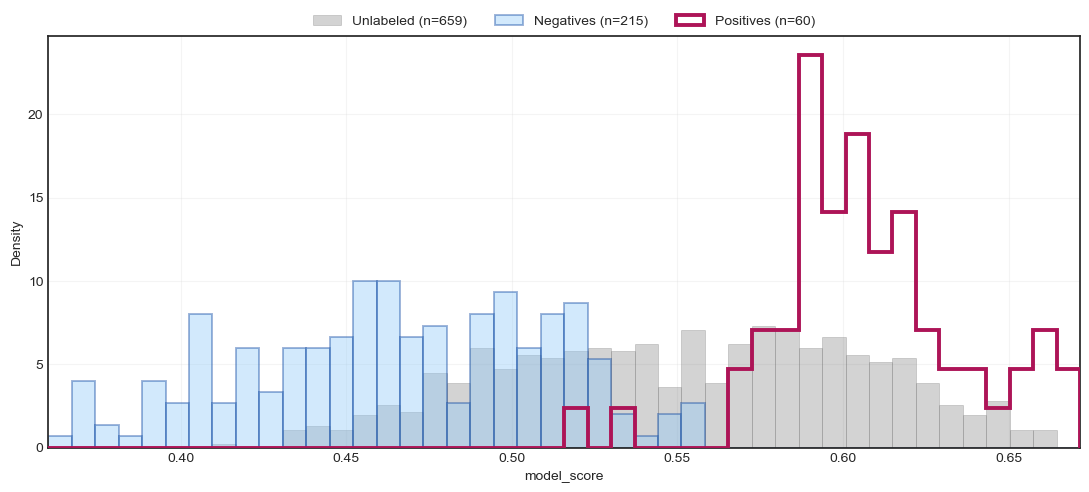

In [31]:
# =======================================================
# 5b) Combined overlay plot (final paper styling)
# =======================================================
COL_UNL_FILL = "#6E6E6E"    # dark gray (unlabeled)
COL_POS_EDGE = "#AD1457"    # dark pink margin (positives)
COL_NEG_FILL = "#90CAF9"    # light blue fill (negatives)
COL_NEG_EDGE = "#0D47A1"    # dark blue margin (negatives)

plt.figure(figsize=(11, 5))

# Unlabeled: dark gray filled
plt.hist(
    unl_scores,
    bins=bins,
    density=True,
    alpha=0.30,
    color=COL_UNL_FILL,
    edgecolor=COL_UNL_FILL,
    linewidth=0.6,
    label=f"Unlabeled (n={len(unl_scores)})",
    zorder=1,
)

# Negatives: blue filled with dark blue margin
plt.hist(
    neg_scores,
    bins=bins,
    density=True,
    alpha=0.40,
    color=COL_NEG_FILL,
    edgecolor=COL_NEG_EDGE,
    linewidth=1.4,
    label=f"Negatives (n={len(neg_scores)})",
    zorder=2,
)

# Positives: unfilled with dark pink margin
plt.hist(
    pos_scores,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.8,
    color=COL_POS_EDGE,
    label=f"Positives (n={len(pos_scores)})",
    zorder=4,
)

plt.xlim(x_min, x_max)
plt.xlabel("model_score")
plt.ylabel("Density")
plt.grid(alpha=0.2)

# Legend / description at upper center
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.savefig("Results/APPNP_.png",
            dpi=300, bbox_inches="tight")
plt.show()
